In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

from studio_preprocessing_tools import *

## Loading amiE data (AMIE_PSEAE_Wrenbeck_2017)

In [2]:
amiE_wt_seq = 'MRHGDISSSNDTVGVAVVNYKMPRLHTAAEVLDNARKIAEMIVGMKQGLPGMDLVVFPEYSLQGIMYDPAEMMETAVAIPGEETEIFSRACRKANVWGVFSLTGERHEEHPRKAPYNTLVLIDNNGEIVQKYRKIIPWCPIEGWYPGGQTYVSEGPKGMKISLIICDDGNYPEIWRDCAMKGAELIVRCQGYMYPAKDQQVMMAKAMAWANNCYVAVANAAGFDGVYSYFGHSAIIGFDGRTLGECGEEEMGIQYAQLSLSQIRDARANDQSQNHLFKILHRGYSGLQASGDGDRGLAECPFEFYRTWVTDAEKARENVERLTRSTTGVAQCPVGRLPYEGLEKEA'

pro_df = pd.read_csv("../../raw_data/amiESelectionFitnessData_Propionamide.txt", sep="\t")
iso_df = pd.read_csv("../../raw_data/amiESelectionFitnessData_Isobutyramide.txt", sep="\t")
ace_df = pd.read_csv("../../raw_data/amiESelectionFitnessData_Acetamide.txt", sep="\t")

def get_variant_name(loc, mut):
    return amiE_wt_seq[loc-1]+str(loc)+mut

ace_df = ace_df.set_index(pd.Index([get_variant_name(row.location, row.mutation) for n,row in ace_df.iterrows()])).rename(columns={"normalized_fitness":"acetamide_fitness"}).replace("NS", np.nan)
pro_df = pro_df.set_index(pd.Index([get_variant_name(row.location, row.mutation) for n,row in pro_df.iterrows()])).rename(columns={"normalized_fitness":"propionamide_fitness"}).replace("NS", np.nan)
iso_df = iso_df.set_index(pd.Index([get_variant_name(row.location, row.mutation) for n,row in iso_df.iterrows()])).rename(columns={"normalized_fitness":"isobutyramide_fitness"}).replace("NS", np.nan)

amiE_dataset = pd.concat([ace_df.acetamide_fitness.astype('float'), 
                          pro_df.propionamide_fitness.astype('float'), 
                          iso_df.isobutyramide_fitness.astype('float')], axis=1)
amiE_dataset = amiE_dataset.loc[['*' not in i for i in amiE_dataset.index]]
amiE_dataset

,acetamide_fitness,propionamide_fitness,isobutyramide_fitness
M1F,-1.7829,-1.3118,-0.6809
M1W,NaN,NaN,-0.5174
M1Y,NaN,NaN,-0.5253
M1P,-2.1514,-1.1457,-0.5154
M1M,0.0000,0.0000,0.0000
...,...,...,...
G341D,0.1300,0.1685,0.0331
G341E,0.0272,-0.0451,-0.0263
G341H,-0.1865,-0.1954,-0.0578
G341K,0.0378,-0.1328,-0.1361


(-7.5, 1.0)

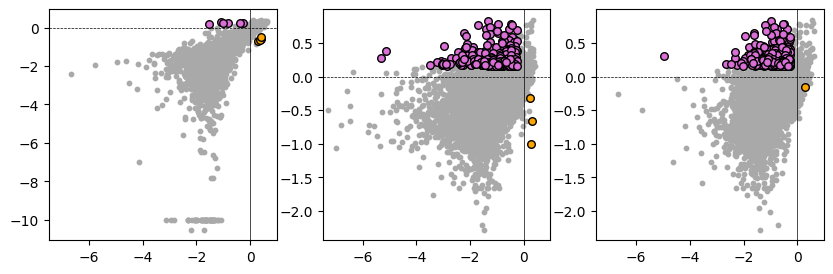

In [3]:
#plt.scatter(data=amiE_dataset.dropna(), x="acetamide_fitness", y="isobutyramide_fitness", ec='k')

fig, ax = plt.subplots(1,3, figsize=(10,3), sharex=True)

ax[0].axvline(0,lw=0.5, c='k'); ax[0].axhline(0,lw=0.5, c='k', ls='dashed')
ax[0].scatter(data=amiE_dataset.dropna(), x="propionamide_fitness", y="acetamide_fitness", 
                s=10, c='darkgray')

ax[0].scatter(data=selector(amiE_dataset, {"acetamide_fitness":lambda x:x>0.15, 'propionamide_fitness':lambda x:x<-0.25}),
            x="propionamide_fitness", y="acetamide_fitness", 
                s=30, ec='k', c='orchid')

ax[0].scatter(data=selector(amiE_dataset, {"propionamide_fitness":lambda x:x>0.25, 'acetamide_fitness':lambda x:x<-0.15}),
            x="propionamide_fitness", y="acetamide_fitness", 
                s=30, ec='k', c='orange')

ax[0].set_xlim(-7.5,1)

ax[1].axvline(0,lw=0.5, c='k'); ax[1].axhline(0,lw=0.5, c='k', ls='dashed')
ax[1].scatter(data=amiE_dataset.dropna(), x="acetamide_fitness", y="isobutyramide_fitness", 
                s=10, c='darkgray')

ax[1].scatter(data=selector(amiE_dataset, {"isobutyramide_fitness":lambda x:x>0.15, 'acetamide_fitness':lambda x:x<-0.25}),
            x="acetamide_fitness", y="isobutyramide_fitness", 
                s=30, ec='k', c='orchid')

ax[1].scatter(data=selector(amiE_dataset, {"acetamide_fitness":lambda x:x>0.25, 'isobutyramide_fitness':lambda x:x<-0.15}),
            x="acetamide_fitness", y="isobutyramide_fitness", 
                s=30, ec='k', c='orange')

ax[1].set_xlim(-9,1)

ax[2].axvline(0,lw=0.5, c='k'); ax[2].axhline(0,lw=0.5, c='k', ls='dashed')
ax[2].scatter(data=amiE_dataset.dropna(), x="propionamide_fitness", y="isobutyramide_fitness", 
                s=10, c='darkgray')

ax[2].scatter(data=selector(amiE_dataset, {"isobutyramide_fitness":lambda x:x>0.15, 'propionamide_fitness':lambda x:x<-0.25}),
            x="propionamide_fitness", y="isobutyramide_fitness", 
                s=30, ec='k', c='orchid')

ax[2].scatter(data=selector(amiE_dataset, {"propionamide_fitness":lambda x:x>0.25, 'isobutyramide_fitness':lambda x:x<-0.15}),
            x="propionamide_fitness", y="isobutyramide_fitness", 
                s=30, ec='k', c='orange')

ax[2].set_xlim(-7.5,1)

In [4]:
categories = {}

for variant, row in amiE_dataset.iterrows():
    
    under_low_thresh = row[['acetamide_fitness', 'propionamide_fitness', 'isobutyramide_fitness']] < np.array([-1, -0.75, -0.35])
    over_low_thresh = row[['acetamide_fitness', 'propionamide_fitness', 'isobutyramide_fitness']] > np.array([-1, -0.75, -0.35])
    over_high_thresh = row[['acetamide_fitness', 'propionamide_fitness', 'isobutyramide_fitness']] > np.array([0.25, 0.25, 0.15])
    over_mid_thresh = row[['acetamide_fitness', 'propionamide_fitness', 'isobutyramide_fitness']] > np.array([-0.15, -0.25, -0.15])
    under_mid_thresh = row[['acetamide_fitness', 'propionamide_fitness', 'isobutyramide_fitness']] < np.array([-0.25, -0.25, -0.15])

    
    if np.any(over_high_thresh) and np.any(under_mid_thresh):
        categories[variant] = "altered-specificity"
    elif np.any(over_mid_thresh) and np.any(under_low_thresh):
        categories[variant] = "altered-specificity"
    elif np.all(under_low_thresh):
        categories[variant] = "inactive"
    elif np.all(over_low_thresh):
        categories[variant] = "native-specificity"
    else:
        categories[variant] = "other"
    # else:
    #     print(variant, over_low_thresh, under_low_thresh, over_high_thresh, under_mid_thresh, over_mid_thresh)

amiE_dataset['specificity_category'] = categories
print(pd.Series(categories, name="category").value_counts())

category
native-specificity     2568
inactive               1860
other                  1344
altered-specificity    1048
Name: count, dtype: int64


In [10]:
amiE_dataset['DMS_score'] = amiE_dataset['acetamide_fitness'].copy()

# amiE_dataset = assign_specificity_categories(amiE_dataset,
#                               lambda index,row:row.propiomaide_fitness < ,
#                               lambda index,row:d.loc[index]>0.55)

amiE_dataset = assign_mutant_column(amiE_dataset)
amiE_dataset['n_subs'] = [i.count(':')+1 if i!='M1M' else 0 for i in amiE_dataset.mutant]
amiE_dataset['mutated_sequence'] = [apply_mutations(amiE_wt_seq, muts) for muts in amiE_dataset.mutant]

check_dataset(amiE_dataset)

#amiE_dataset.to_csv("../../processed_data/AMIE_PSEAE_Wrenbeck_2017.csv")

Checking dataset table:
✅ DMS_score in table
✅ mutated_sequence in table
✅ mutant in table
✅ Contains WT sequence (M1M)
✅ all mutants pass checks and match sequence

✅ All checks passed!


In [ ]:
np.savetxt('../../processed_data/amiE_dataset.mut', amiE_dataset.mutant.values, fmt="%s")
np.savetxt('../../processed_data/amiE_dataset.mut', [i.replace(':',',') for i in amiE_dataset.mutant.values], fmt="%s")

In [14]:
amiE_dataset.loc['altered-specificity']

KeyError: 'altered-specificity'

In [15]:
def get_specificity_positions(df):
    sp_muts = selector(df, {'specificity_category': 'altered-specificity'}).mutant
    return pd.Series([i[1:-1] for i in sp_muts]).value_counts()

norA_sp_pos = get_specificity_positions(amiE_dataset)
print('+'.join(norA_sp_pos.index))

# for pos,n in get_specificity_positions(amiE_dataset).items():
#     print(f"set sphere_scale, {n/10}, _specificity and res {pos};")

for pos,n in norA_sp_pos.items():
    print(f"set sphere_scale, {n/10}, amiE_specificity and res {pos};")

249+286+284+290+323+291+332+324+329+271+50+248+7+292+273+322+287+293+274+197+275+202+247+277+257+251+303+296+333+180+139+246+113+327+241+276+250+312+297+299+311+223+307+306+209+228+201+151+316+254+11+212+199+171+281+204+71+3+196+141+234+252+319+320+130+51+242+270+272+136+314+313+198+334+217+232+245+298+5+210+200+259+12+285+153+238+265+289+309+315+174+203+321+326+106+138+150+266+302+213+190+6+23+205+301+288+225+280+108+20+149+331+9+145+243+262+261+119+181+147+131+21+148+93+279+295+75+189+80+216+218+206+193+230+179+255+253+165+114+267+264+263+278+178+118+237+135+258+2+4+10+18+8+325+328+330+19+317+194+60+62+63+65+66+24+25+236+154+156+159+160+163+268+269+115+120+125+127+128+173+177+226+227+98+107+109+112+211+219+220+222+282+283+294+74+79+84+86+87+91+300+304+185+186+191+192+26+31+41+44+49+14+17+1+335+337+167+143+133+140+260+231
set sphere_scale, 1.9, amiE_specificity and res 249;
set sphere_scale, 1.7, amiE_specificity and res 286;
set sphere_scale, 1.7, amiE_specificity and res 284;
set sp

In [13]:
norA_sp_pos

249    19
286    17
284    17
290    17
323    16
       ..
143     1
133     1
140     1
260     1
231     1
Name: count, Length: 222, dtype: int64